<a href="https://colab.research.google.com/github/SalmiFatimaZahra/Gestion-des-salaires-des-employ-s-dans-une-entreprise-/blob/main/Projet_Big_Data_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Ingestion

In [ ]:
pip install pandas openpyxl

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

print(df.shape)

(541909, 8)


In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import os

print(os.listdir())

['.config', 'online_retail_II.xlsx', 'online_retail_II (1).xlsx', 'Online Retail.xlsx', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_excel("online_retail_II (1).xlsx")

print(df.shape)

(525461, 8)


In [ ]:
import os

print(os.listdir())

['.config', 'online_retail_II.xlsx', 'Online Retail.xlsx', 'sample_data']


In [ ]:
import pandas as pd

df1 = pd.read_excel("Online Retail.xlsx")
df2 = pd.read_excel("online_retail_II (1).xlsx")

In [ ]:
print(df1.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [ ]:
print(df2.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')


In [ ]:
df2 = df2.rename(columns={
    'Invoice': 'InvoiceNo',
    'Price': 'UnitPrice',
    'Customer ID': 'CustomerID'
})

In [ ]:
df = pd.concat([df1, df2], ignore_index=True)

print(df.shape)

(1067370, 8)


In [ ]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


#Data Preprocessing

In [ ]:
df = df.rename(columns={
    'Invoice': 'InvoiceNo',
    'Price': 'UnitPrice',
    'Customer ID': 'CustomerID'
})

In [ ]:
df = df.dropna()

In [ ]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [ ]:
print(df.head())
print("\nShape:", df.shape)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom       22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  

Shape: (805548, 9)


#RFM Analysis

In [ ]:
import datetime as dt

# date de référence (dernier achat + 1 jour)
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

In [ ]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [ ]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [ ]:
print(rfm.head())
print(rfm.describe())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326         12  77556.46
12347.0           2          8   5633.32
12348.0          75          5   2019.40
12349.0          19          4   4428.69
12350.0         310          1    334.40
           Recency    Frequency       Monetary
count  5878.000000  5878.000000    5878.000000
mean    201.331916     6.289384    3018.613674
std     209.338707    13.009406   14737.731486
min       1.000000     1.000000       2.950000
25%      26.000000     1.000000     348.762500
50%      96.000000     3.000000     898.915000
75%     380.000000     7.000000    2307.090000
max     739.000000   398.000000  608821.650000


In [ ]:
rfm.sort_values(by='Monetary', ascending=False).head(10)

,Recency,Frequency,Monetary
CustomerID,,,
18102.0,1,145,608821.65
14646.0,2,151,528602.52
14156.0,10,156,313946.37
14911.0,1,398,295972.63
17450.0,8,51,246973.09
13694.0,4,143,196482.81
17511.0,3,60,175603.55
16446.0,1,2,168472.50
16684.0,4,55,147142.77


#Machine Learning (KMeans)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [ ]:
print(rfm.head())

            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346.0         326         12  77556.46        1
12347.0           2          8   5633.32        1
12348.0          75          5   2019.40        1
12349.0          19          4   4428.69        1
12350.0         310          1    334.40        0


In [ ]:
rfm['Cluster'].value_counts()

,count
Cluster,
1,3841
0,1998
2,35
3,4


In [ ]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,463.032032,2.212212,765.244446
1,67.005728,7.307732,3009.397764
2,25.942857,103.714286,83086.079771
3,3.500000,212.500000,436835.792500


#Recommandation System

In [ ]:
pivot = df.pivot_table(index='CustomerID',
                       columns='StockCode',
                       values='Quantity',
                       fill_value=0)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(pivot)

In [ ]:
import numpy as np

def recommend_products(customer_id, pivot, similarity, top_n=5):
    idx = pivot.index.get_loc(customer_id)
    sim_scores = list(enumerate(similarity[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    similar_users = [i[0] for i in sim_scores]

    return pivot.iloc[similar_users].sum().sort_values(ascending=False).head(top_n)

print(recommend_products(12347.0, pivot, similarity))

StockCode
23076    372.0
23077    100.0
22422     48.0
22084     48.0
22741     48.0
dtype: float64


In [ ]:
product_names = df[['StockCode', 'Description']].drop_duplicates()

recommendations = recommend_products(12347.0, pivot, similarity).reset_index()
recommendations.columns = ['StockCode', 'Score']

recommendations = recommendations.merge(product_names, on='StockCode', how='left')

print(recommendations)

  StockCode  Score                 Description
0     23076  372.0  ICE CREAM SUNDAE LIP GLOSS
1     23077  100.0         DOUGHNUT LIP GLOSS 
2     22422   48.0         TOOTHPASTE TUBE PEN
3     22084   48.0      PAPER CHAIN KIT EMPIRE
4     22741   48.0              FUNKY DIVA PEN


In [ ]:
# Sauvegarder dataset principal
df.to_csv("transactions_clean.csv", index=False)

# Sauvegarder RFM
rfm.to_csv("rfm.csv")

# Sauvegarder résultats clustering
rfm.to_csv("rfm_clusters.csv")

In [ ]:
def recommend_products(customer_id, pivot, similarity, top_n=5):

    # index client
    idx = pivot.index.get_loc(customer_id)

    # similarité
    sim_scores = list(enumerate(similarity[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    similar_users = [i[0] for i in sim_scores]

    # produits des utilisateurs similaires
    recommended = pivot.iloc[similar_users].sum()

    # produits déjà achetés par le client
    already_bought = pivot.iloc[idx]
    already_bought = already_bought[already_bought > 0].index

    # enlever produits déjà achetés
    recommended = recommended.drop(already_bought, errors='ignore')

    return recommended.sort_values(ascending=False).head(top_n)

In [ ]:
recommend_products(12347.0, pivot, similarity)

,0
StockCode,
23076,372.0
23077,100.0
22422,48.0
22084,48.0
22741,48.0


#Visualisation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
total_revenue = df['TotalPrice'].sum()
total_customers = df['CustomerID'].nunique()
total_orders = df['InvoiceNo'].nunique()

print("CA total :", total_revenue)
print("Nombre clients :", total_customers)
print("Nombre commandes :", total_orders)

CA total : 17743411.178000007
Nombre clients : 5878
Nombre commandes : 36969


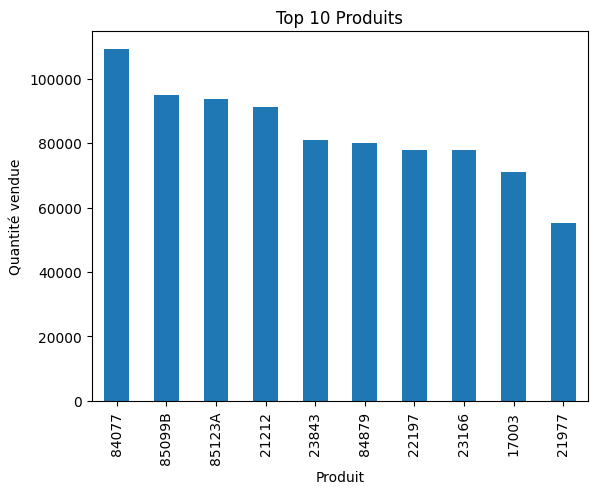

In [ ]:
top_products = df.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top 10 Produits")
plt.xlabel("Produit")
plt.ylabel("Quantité vendue")
plt.show()

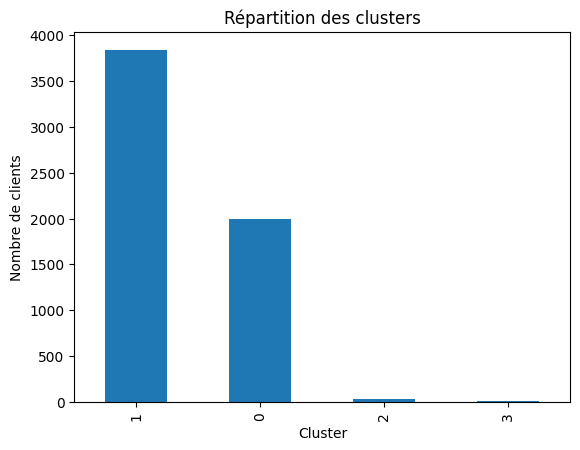

In [ ]:
cluster_counts = rfm['Cluster'].value_counts()

cluster_counts.plot(kind='bar')
plt.title("Répartition des clusters")
plt.xlabel("Cluster")
plt.ylabel("Nombre de clients")
plt.show()

#DATA STORAGE

In [ ]:
import sqlite3

# créer base
conn = sqlite3.connect("ecommerce.db")
cursor = conn.cursor()

In [ ]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS transactions (
    InvoiceNo TEXT,
    StockCode TEXT,
    Description TEXT,
    Quantity INTEGER,
    InvoiceDate TEXT,
    UnitPrice REAL,
    CustomerID REAL,
    Country TEXT,
    TotalPrice REAL
)
""")

conn.commit()

In [ ]:
df.to_sql("transactions", conn, if_exists="replace", index=False)

805548

In [ ]:
result = pd.read_sql("SELECT * FROM transactions LIMIT 5", conn)
print(result)

   InvoiceNo StockCode                          Description  Quantity  \
0     536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1     536365     71053                  WHITE METAL LANTERN         6   
2     536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3     536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4     536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom       22.00  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  


#Spark

In [ ]:
!apt-get install openjdk-11-jdk -y
!pip install pyspark

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core fonts-dejavu-core fonts-dejavu-extra gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk-wrapper-java libatk-wrapper-java-jni libatk1.0-0
  libatk1.0-data libatspi2.0-0 libxcomposite1 libxt-dev libxtst6 libxxf86dga1
  openjdk-11-jdk-headless openjdk-11-jre openjdk-11-jre-headless
  session-migration x11-utils
Suggested packages:
  libxt-doc openjdk-11-demo openjdk-11-source visualvm libnss-mdns
  fonts-ipafont-gothic fonts-ipafont-mincho fonts-wqy-microhei
  | fonts-wqy-zenhei fonts-indic mesa-utils
The following NEW packages will be installed:
  at-spi2-core fonts-dejavu-core fonts-dejavu-extra gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk-wrapper-java libatk-wrapper-java-jni libatk1.0-0
  libatk1.0-data libatspi2.0-0 libxcomposite1 libxt-dev libxtst6 libxxf86dga1
  openjdk-11-jdk openjdk-11-jdk-headless openjdk-

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Ecommerce Big Data Project") \
    .getOrCreate()

In [ ]:
df_spark = spark.createDataFrame(df)
df_spark.show(5)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+------------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|        TotalPrice|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+------------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|2010-12-01 08:26:00|     2.55|   17850.0|United Kingdom|15.299999999999999|
|   536365|    71053| WHITE METAL LANTERN|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|             20.34|
|   536365|   84406B|CREAM CUPID HEART...|       8|2010-12-01 08:26:00|     2.75|   17850.0|United Kingdom|              22.0|
|   536365|   84029G|KNITTED UNION FLA...|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|             20.34|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|    

In [ ]:
from pyspark.sql.functions import col

df_spark = df_spark \
    .filter(col("Quantity") > 0) \
    .filter(col("CustomerID").isNotNull())

In [ ]:
df_spark = df_spark.withColumn(
    "TotalPrice",
    col("Quantity") * col("UnitPrice")
)

In [ ]:
from pyspark.sql import functions as F

snapshot_date = df_spark.agg(F.max("InvoiceDate")).collect()[0][0]

rfm_spark = df_spark.groupBy("CustomerID").agg(
    F.datediff(F.lit(snapshot_date), F.max("InvoiceDate")).alias("Recency"),
    F.count("InvoiceNo").alias("Frequency"),
    F.sum("TotalPrice").alias("Monetary")
)

rfm_spark.show(5)

+----------+-------+---------+-----------------+
|CustomerID|Recency|Frequency|         Monetary|
+----------+-------+---------+-----------------+
|   16916.0|     23|      264|           1123.4|
|   17884.0|      3|      482|3072.889999999998|
|   13094.0|     21|       32|          2433.12|
|   16596.0|     15|       30|           579.63|
|   18114.0|    290|       28|            220.1|
+----------+-------+---------+-----------------+
only showing top 5 rows


In [ ]:
rfm_pandas = rfm_spark.toPandas()

In [ ]:
rfm_pandas.to_sql("rfm", conn, if_exists="replace", index=False)

5878

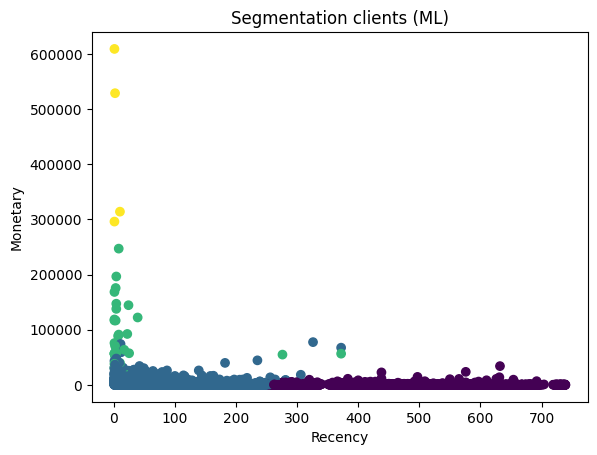

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'])
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Segmentation clients (ML)")
plt.show()

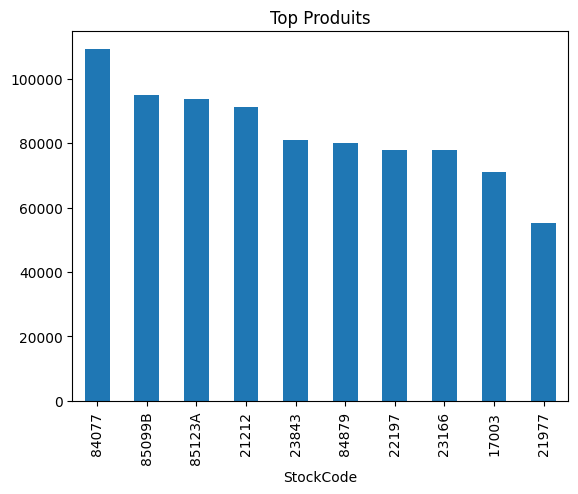

In [ ]:
top_products = df.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top Produits")
plt.show()

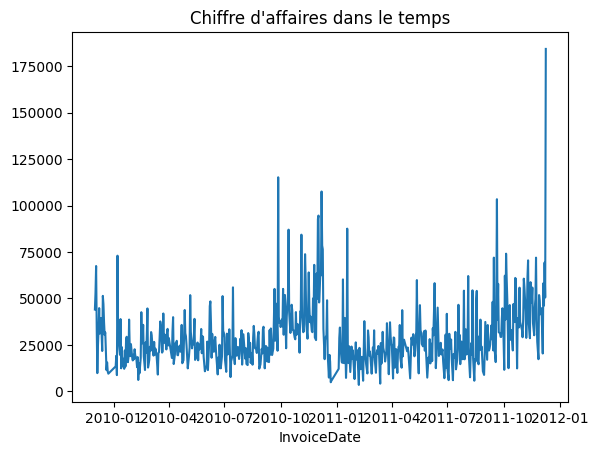

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

sales = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum()

sales.plot()
plt.title("Chiffre d'affaires dans le temps")
plt.show()

In [ ]:
print(recommendations)

  StockCode  Score                 Description
0     23076  372.0  ICE CREAM SUNDAE LIP GLOSS
1     23077  100.0         DOUGHNUT LIP GLOSS 
2     22422   48.0         TOOTHPASTE TUBE PEN
3     22084   48.0      PAPER CHAIN KIT EMPIRE
4     22741   48.0              FUNKY DIVA PEN
